#  EHR Data Understanding — Part 1: Exploring the Synthea Dataset

In this notebook, you'll explore the structure of Electronic Health Record (EHR) data from Synthea, a synthetic patient generator. Understanding the data model and relationships between tables is essential before building any clinical analytics or machine learning pipelines.

---

##  What You'll Do Today

1. **Load and inspect** all EHR data tables (patients, encounters, conditions, medications, observations, procedures, allergies)

2. **Analyze patient demographics** including gender, race, and age distributions

3. **Explore encounter patterns** to understand clinical visit frequency and types

4. **Assess data sufficiency** for statistical analysis and ML model building

5. **Understand the PatientProfile class** that consolidates scattered EHR data

---

##  Why Data Understanding Matters

Real EHR systems store data across multiple related tables following healthcare data standards like FHIR and HL7. Before building any analytical pipeline, you need to understand:

- **Data structure**: Which tables exist and what they contain
- **Data sufficiency**: Do we have enough samples for statistical significance?
- **Representativeness**: Is the patient population representative of the target population?

By the end of this notebook, you'll have assessed whether this dataset is sufficient for building patient risk models.

## Setting Environment Up for Colab

Mount Google Drive and download the dataset so this notebook can access the EHR data.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Set your Google Drive path here
# Replace <PATH_TO_REPO> with your actual repository path
REPO_PATH = "/content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo"

# Data directory for Week 1
DATA_DIR = f"{REPO_PATH}/data/ehr_data"

print(f"Repository path: {REPO_PATH}")
print(f"Data directory: {DATA_DIR}")

Repository path: /content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo
Data directory: /content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo/data/ehr_data


---

##  Step 1: Import Libraries

Before we begin exploring the data, we need to import the essential Python libraries:

- **pandas**: For loading and manipulating tabular data (our CSV files)
- **numpy**: For numerical operations and handling missing values
- **matplotlib & seaborn**: For creating visualizations to understand data distributions
- **os**: For constructing file paths across different operating systems

These libraries form the foundation of any data science workflow in Python.

In [3]:
# (provided)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(" Libraries imported successfully")

 Libraries imported successfully


---

##  Step 2: Load All EHR Data Tables

Electronic Health Record (EHR) systems organize patient data into multiple related tables, following healthcare data standards like HL7 FHIR. The Synthea dataset mimics this real-world structure with 7 CSV files, each representing a different aspect of patient care:

| Table | Description | Key Fields |
|-------|-------------|------------|
| **patients** | Patient demographics and identifiers | id, birthdate, gender, race |
| **encounters** | Clinical visits and appointments | id, patient, date, description |
| **conditions** | Diagnoses and medical conditions | patient, encounter, code, description |
| **medications** | Prescribed drugs and treatments | patient, encounter, description |
| **observations** | Lab results, vital signs, measurements | patient, encounter, value, units |
| **procedures** | Medical procedures performed | patient, encounter, description |
| **allergies** | Known patient allergies | patient, description |

**Understanding the Relationships:**
- **PATIENTS** is the root table — every other table references it via a patient ID
- **ENCOUNTERS** is the central hub — most clinical events (conditions, medications, observations) occur during an encounter
- This relational structure allows us to reconstruct a complete patient timeline

 **Important**: This dataset contains data quality issues (duplicates, invalid records, OCR errors) that you'll learn to clean in Part 2.

In [4]:
# (provided)
# Load all 7 EHR tables
patients = pd.read_csv(os.path.join(DATA_DIR, "csv/patients.csv"))
encounters = pd.read_csv(os.path.join(DATA_DIR, "csv/encounters.csv"))
conditions = pd.read_csv(os.path.join(DATA_DIR, "csv/conditions.csv"))
medications = pd.read_csv(os.path.join(DATA_DIR, "csv/medications.csv"))
observations = pd.read_csv(os.path.join(DATA_DIR, "csv/observations.csv"))
procedures = pd.read_csv(os.path.join(DATA_DIR, "csv/procedures.csv"))
allergies = pd.read_csv(os.path.join(DATA_DIR, "csv/allergies.csv"))

print("All 7 tables loaded:")
for name, df in [('patients', patients), ('encounters', encounters),
                  ('conditions', conditions), ('medications', medications),
                  ('observations', observations), ('procedures', procedures),
                  ('allergies', allergies)]:
    print(f"  {name}: {len(df):,} rows, {len(df.columns)} columns")

All 7 tables loaded:
  patients: 10,100 rows, 17 columns
  encounters: 73,544 rows, 7 columns
  conditions: 31,589 rows, 6 columns
  medications: 25,190 rows, 8 columns
  observations: 345,083 rows, 7 columns
  procedures: 37,287 rows, 7 columns
  allergies: 2,739 rows, 6 columns


###  Helper Function for Column Name Inconsistency

One common challenge when working with real-world healthcare data is **inconsistent column naming**. In the Synthea dataset:

- `patients.csv` and `encounters.csv` use **UPPERCASE** column names (e.g., `ID`, `PATIENT`)
- Some columns might use different cases across tables (e.g., `patient` vs `PATIENT`)

This inconsistency can cause frustrating `KeyError` exceptions when filtering data. To handle this gracefully, we'll create a helper function that performs **case-insensitive column lookups**.

This is a common pattern in data engineering — always build robust utilities that handle real-world data messiness!

** ACTION REQUIRED:** After running the cell below, copy the `get_col` function to `src/helpers.py`. You will import it from there in future notebooks.

In [5]:
# (provided)
# TODO: Copy this function to src/helpers.py, then import it from there

def get_col(df, name):
    """Find column by name, case-insensitive."""
    for col in df.columns:
        if col.lower() == name.lower():
            return col
    return None

print(" get_col defined - NOW COPY IT TO src/helpers.py")

 get_col defined - NOW COPY IT TO src/helpers.py


---

##  Step 3: Table Overview — Understanding Data Scale

Before diving into analysis, it's crucial to understand the **scale and structure** of each table. This initial overview helps us:

1. **Assess data volume**: Do we have enough records for statistical analysis and ML training?
2. **Understand table dimensions**: How many columns (features) are available in each table?
3. **Identify the largest tables**: Which tables will require the most computational resources?

Let's examine the row counts and column counts for all 7 tables:

In [6]:
# (provided)
tables = {
    'patients': patients,
    'encounters': encounters,
    'conditions': conditions,
    'medications': medications,
    'observations': observations,
    'procedures': procedures,
    'allergies': allergies
}

print("TABLE SIZES")
print("=" * 60)
for name, df in tables.items():
    print(f"{name:15} {len(df):>10,} rows  x  {len(df.columns):>2} columns")

TABLE SIZES
patients            10,100 rows  x  17 columns
encounters          73,544 rows  x   7 columns
conditions          31,589 rows  x   6 columns
medications         25,190 rows  x   8 columns
observations       345,083 rows  x   7 columns
procedures          37,287 rows  x   7 columns
allergies            2,739 rows  x   6 columns


In [7]:
# (provided)
# Show column names for each table
print("COLUMN NAMES BY TABLE")
print("=" * 60)
for name, df in tables.items():
    print(f"\n{name.upper()}:")
    print(f"  {list(df.columns)}")

COLUMN NAMES BY TABLE

PATIENTS:
  ['ID', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS']

ENCOUNTERS:
  ['ID', 'DATE', 'PATIENT', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']

CONDITIONS:
  ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']

MEDICATIONS:
  ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']

OBSERVATIONS:
  ['DATE', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'VALUE', 'UNITS']

PROCEDURES:
  ['DATE', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']

ALLERGIES:
  ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']


---

##  Step 4: Patient Demographics Analysis

Demographics are the foundation of any healthcare analysis. Understanding your patient population helps you:

- **Identify potential biases**: Is your data representative of the target population?
- **Enable stratified analysis**: Can you analyze outcomes by gender, race, or age group?
- **Assess ML model fairness**: Will your model perform equally well across demographic groups?

We'll examine three key demographic dimensions:
1. **Gender distribution**: Balance between male and female patients
2. **Race/ethnicity distribution**: Representation of different racial groups
3. **Age distribution**: Range and central tendency of patient ages

Let's start by extracting basic demographic statistics:

> **Your Task 1.1: Analyze Patient Demographics**
> 1. Get total patient count using `len()`
> 2. Use `get_col()` to find the gender and race columns
> 3. Use `.value_counts()` to show distributions for each

In [14]:
print("PATIENT DEMOGRAPHICS")
print("=" * 50)

# TODO: Get total number of patients
total_patients = len(patients)
print(f"Total patients: {total_patients:,}")

# TODO: Get column names using get_col()
gender_col = get_col(patients, 'GENDER')
race_col = get_col(patients, 'RACE')

# TODO: Get gender distribution
print(f"\nGender distribution:")
gender_counts = patients[gender_col].value_counts()
print(gender_counts)

# TODO: Get race distribution
print(f"\nRace distribution:")
race_counts = patients[race_col].value_counts()
print(race_counts)

PATIENT DEMOGRAPHICS
Total patients: 10,100

Gender distribution:
GENDER
F                              5103
M                              4981
Littleton MA US                   1
Wayland MA US                     1
Woburn MA US                      1
West Springfield Town MA US       1
New Bedford MA US                 1
Name: count, dtype: int64

Race distribution:
RACE
white       9132
hispanic     438
black        353
asian        161
french         2
english        1
german         1
irish          1
Name: count, dtype: int64


> **Your Task 1.2: Calculate Patient Ages**
> 1. Get the birthdate column using `get_col()`
> 2. Parse dates with `pd.to_datetime(..., errors='coerce')`
> 3. Calculate age: `(pd.Timestamp.now() - birthdate).dt.days // 365`
> 4. Compute min, max, mean, median age statistics

In [28]:
# TODO: Get the birthdate column name
birthdate_col = get_col(patients,'birthdate')  # Find the birthdate column

# TODO: Parse dates with error handling (coerce invalid dates to NaT)
patients['birthdate_parsed'] = pd.to_datetime(patients[birthdate_col], errors='coerce')  # Convert birthdate column to datetime

# TODO: Count valid vs invalid birthdates
valid_dates = patients[birthdate_col].value_counts(dropna=True).count()  # Count non-null parsed dates
invalid_dates = len(patients[birthdate_col]) - valid_dates  # Count null parsed dates

print(f"Date parsing results:")
print(f"  Valid birthdates: {valid_dates:,}")
print(f"  Invalid/missing:  {invalid_dates:,}")

# TODO: Calculate age only for valid dates
patients['age'] = np.nan
valid_mask = patients['birthdate_parsed'].notna()
# Calculate days since birth, then divide by 365
patients.loc[valid_mask, 'age'] = (pd.Timestamp.now() - patients['birthdate_parsed']).dt.days // 365 # Fill in the calculation

# TODO: Calculate age statistics
min_age = patients['age'].min()  # Minimum age
max_age = patients['age'].max()  # Maximum age
mean_age = patients['age'].mean()  # Average age
median_age = patients['age'].median()  # Median age

print("\nAge Distribution (valid dates only):")
print(f"  Min age:    {min_age:.0f} years")
print(f"  Max age:    {max_age:.0f} years")
print(f"  Mean age:   {mean_age:.1f} years")
print(f"  Median age: {median_age:.0f} years")

if invalid_dates > 0:
    print(f"\n Warning: {invalid_dates} rows have invalid birthdate values (data quality issue)")

Date parsing results:
  Valid birthdates: 8,658
  Invalid/missing:  1,442

Age Distribution (valid dates only):
  Min age:    8 years
  Max age:    119 years
  Mean age:   63.3 years
  Median age: 67 years



###  Visualizing Demographics

Numbers alone don't tell the full story. Visualizations help us quickly identify:
- **Imbalances**: Are any groups severely underrepresented?
- **Outliers**: Are there unexpected values in the data?
- **Distributions**: Is the age distribution normal, skewed, or multimodal?

We'll create three side-by-side charts:
1. **Bar chart**: Gender distribution (categorical)
2. **Horizontal bar chart**: Race distribution (categorical with many values)
3. **Histogram**: Age distribution (continuous variable)

Notice how we filter out invalid data (addresses appearing in gender/race fields) — this is a data quality issue we'll address in Part 2.

> **Your Task 1.3: Create Demographics Visualizations**
> 1. Create a bar chart for gender distribution on `axes[0]`
> 2. Create a horizontal bar chart for race distribution on `axes[1]`
> 3. Create a histogram for age distribution on `axes[2]`
>
> Use pandas `.plot(kind=...)` or matplotlib methods

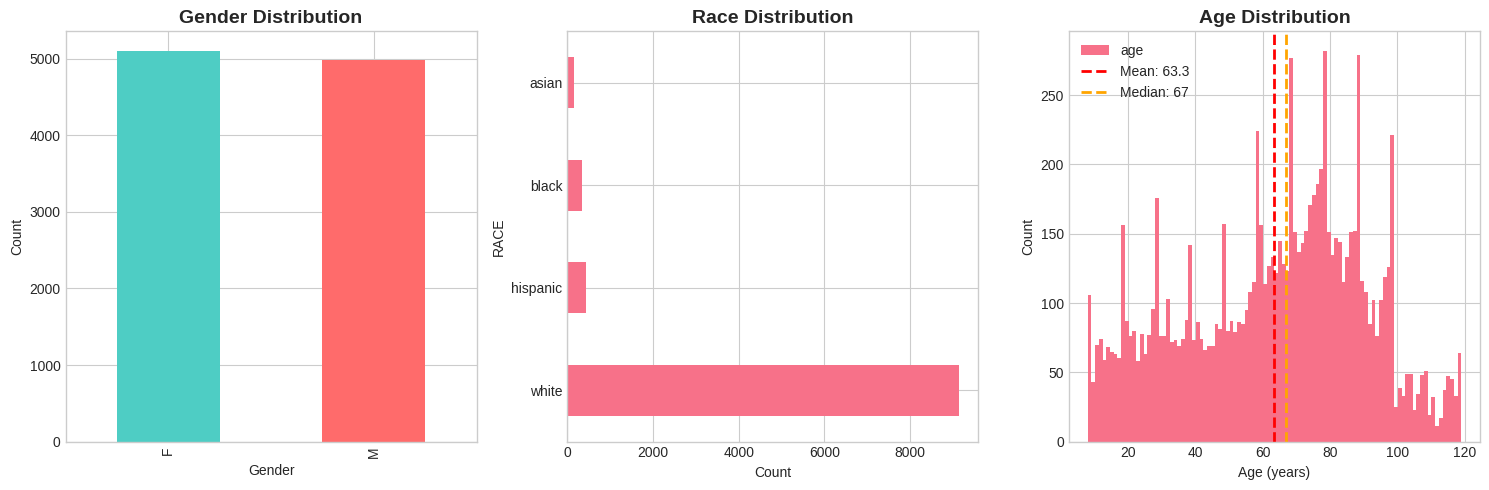

Demographics visualizations complete


In [40]:
# Create demographics visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Filter to valid gender values only (M/F)
gender_counts = patients[gender_col].value_counts()
valid_genders = gender_counts[gender_counts.index.isin(['M', 'F', 'male', 'female'])]

# TODO: Plot gender bar chart on axes[0]
ax1 = axes[0]
colors_gender = ['#4ECDC4', '#FF6B6B']
valid_genders.plot(kind='bar', ax=ax1, color=colors_gender)

# TODO: Create bar chart with valid_genders data
ax1.set_title('Gender Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')


# Filter to valid race values (appear > 100 times, not addresses)
race_counts = patients[race_col].value_counts()
valid_races = race_counts[(race_counts > 100) & (~race_counts.index.str.contains('MA US|Suite|Apt', na=False))]

# TODO: Plot race horizontal bar chart on axes[1]
ax2 = axes[1]
valid_races.plot(kind='barh', ax=ax2)

# TODO: Create horizontal bar chart with valid_races data
ax2.set_title('Race Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Count')

# Get valid ages
valid_ages = patients['age'].dropna()

# TODO: Plot age histogram on axes[2]
ax3 = axes[2]
valid_ages.plot(kind='hist', ax=ax3, bins=100)
# TODO: Create histogram with valid_ages data
ax3.axvline(valid_ages.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_ages.mean():.1f}')
ax3.axvline(valid_ages.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {valid_ages.median():.0f}')
ax3.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Count')
ax3.legend()

plt.tight_layout()
plt.show()

print("Demographics visualizations complete")

---

###  Data Sufficiency Analysis: Demographics

Now let's assess whether our demographic data is sufficient for building ML models.

**Sample Size Considerations:**
- With **[___] patients**, we have sufficient statistical power for:
  - Detecting differences of 5%+ between demographic groups (p<0.05)
  - Building ML models with adequate representation per class
  - Performing stratified analysis across subgroups

**Gender Distribution Assessment:**
- [Describe the M/F split - is it balanced?]
- [Is this representative of the general population?]
- [Any concerns for gender-stratified analysis?]

**Racial Distribution Assessment:**
- [Which racial group dominates? What percentage?]
- [Are minority groups large enough for subgroup analysis?]
- [Any potential bias concerns?]

**Age Distribution Assessment:**
- Age range: [___] to [___] years
- Mean age: ~[___] years
- [Is this appropriate for a diabetes-focused study?]
- [Any concerns about pediatric or geriatric representation?]

**Your Conclusion:** [Write 1-2 sentences summarizing demographic data sufficiency]

---

##  Step 5: Encounter Analysis

**Encounters** are the backbone of EHR data — they represent every interaction between a patient and the healthcare system. Each encounter (visit) is when clinical data gets generated:

- **Outpatient visits**: Routine checkups, follow-ups, specialist consultations
- **Emergency room visits**: Acute care for urgent medical issues
- **Inpatient stays**: Hospitalizations for serious conditions
- **Procedures**: Surgeries, diagnostic tests, treatments

Understanding encounter patterns is critical because:
1. **Longitudinal depth**: How many time points do we have per patient for time-series analysis?
2. **Visit frequency**: Can we detect patterns in healthcare utilization?
3. **Encounter types**: Do we have enough emergency/inpatient visits for predicting adverse events?

Let's analyze the encounter distribution:

> **Your Task 2.1: Analyze Encounter Statistics**
> 1. Get patient and description columns using `get_col()`
> 2. Count total encounters and unique patients
> 3. Calculate encounters per patient using `groupby().size()`
> 4. Print min, max, mean, median statistics

In [ ]:
print("ENCOUNTER STATISTICS")
print("=" * 50)

# TODO: Get column names
patient_col = get_col()  # Find the patient column in encounters
desc_col = None  # Find the description column in encounters

# TODO: Calculate total encounters
total_encounters = None  # How many rows in encounters?
print(f"Total encounters: {total_encounters:,}")

# TODO: Calculate unique patients with encounters
unique_patients = None  # How many distinct patient IDs?
print(f"Unique patients with encounters: {unique_patients:,}")

# TODO: Calculate encounters per patient
enc_per_patient = None  # Group by patient and count

print(f"\nEncounters per patient:")
print(f"  Min:    {enc_per_patient.min()}")
print(f"  Max:    {enc_per_patient.max()}")
print(f"  Mean:   {enc_per_patient.mean():.1f}")
print(f"  Median: {enc_per_patient.median():.0f}")

> **Your Task 2.2: Show Top Encounter Types**
> 1. Count occurrences of each encounter type
> 2. Display the top 10 most common types

In [ ]:
# TODO: Print top 10 encounter types
print("\nTop 10 Encounter Types:")
# Count values in description column, get top 10
top_types = None
print(top_types)

###  Visualizing Encounter Patterns

Two key visualizations help us understand encounter patterns:

1. **Top Encounter Types (left chart)**:
   - Which types of visits are most common?
   - Is outpatient care dominant (as expected in primary care)?
   - How many emergency visits do we have for adverse event prediction?

2. **Encounters per Patient (right chart)**:
   - What's the typical number of visits per patient?
   - Are there patients with very high utilization (chronic/complex cases)?
   - Do we have enough longitudinal data for time-series features?

The red and orange lines show mean and median — a large gap indicates a skewed distribution (common in healthcare data where a small percentage of patients account for a large share of visits).

> **Your Task 2.3: Create Encounter Visualizations**
> 1. Create a horizontal bar chart for top 10 encounter types
> 2. Create a histogram for encounters per patient distribution

In [ ]:
# Encounter visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Get top 10 encounter types
top_enc_types = None

# TODO: Plot horizontal bar chart on axes[0]
ax1 = axes[0]
# TODO: Create horizontal bar chart with top_enc_types data
ax1.set_xlabel('Count')
ax1.set_title('Top 10 Encounter Types', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# TODO: Plot histogram of encounters per patient on axes[1]
ax2 = axes[1]
# TODO: Create histogram with enc_per_patient data
ax2.axvline(enc_per_patient.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {enc_per_patient.mean():.1f}')
ax2.axvline(enc_per_patient.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {enc_per_patient.median():.0f}')
ax2.set_xlabel('Encounters per Patient')
ax2.set_ylabel('Number of Patients')
ax2.set_title('Encounters per Patient Distribution', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("Encounter visualizations complete")

---

###  Data Sufficiency Analysis: Encounters

**Encounter Volume Assessment:**
- **[___] encounters** across **[___] patients** provides:
  - Average of **[___] encounters per patient** — [is this good longitudinal coverage?]
  - [Sufficient/Insufficient] data points for temporal feature engineering
  - [How many time points per patient for time-series modeling?]

**Encounter Type Distribution:**
- **[Which type dominates?]** (~[___]%) — [is this realistic?]
- **Emergency room admissions present** (~[___]%) — [sufficient for ED visit prediction?]
- [Comment on variety of encounter types]

**Encounters per Patient Distribution:**
- Most patients have **[___] encounters** ([describe the distribution shape])
- Some patients have **[___]+ encounters** — [what does this indicate?]
- [Is this distribution realistic for a healthcare system?]
- [Note any data quality concerns - e.g., patients with zero encounters]

**Longitudinal Data Sufficiency:**
- With mean of ~[___] encounters per patient, we can compute:
  - Rolling window features (encounters in last 30/90/180 days)
  - Time-since-last features
  - Trend features (increasing/decreasing visit frequency)

**Your Conclusion:** [Write 1-2 sentences on whether encounter data is sufficient for building patient risk models]

---

##  Overall Data Sufficiency Summary

Fill in this table based on your analysis:

| Dimension | Your Finding | Sufficient? |
|-----------|------------|-------------|
| **Sample Size** | [___] patients | [Yes/No/Caution] |
| **Gender Balance** | [___] M/F split | [Yes/No/Caution] |
| **Racial Diversity** | [describe] | [Yes/No/Caution] |
| **Age Range** | [___] to [___] years, mean ~[___] | [Yes/No/Caution] |
| **Encounter Volume** | [___] total, ~[___]/patient | [Yes/No/Caution] |
| **Encounter Types** | [list main types] | [Yes/No/Caution] |
| **Longitudinal Data** | [describe coverage] | [Yes/No/Caution] |

**Overall Assessment:** [Write 2-3 sentences summarizing whether this dataset is suitable for building diabetes risk prediction models. Note any limitations or concerns.]

---

##  Step 6: Introduction to Patient Profile Classes

### The Problem: Scattered Patient Data

By now you've seen that EHR data is scattered across 7 different tables. To answer a simple question like **"What medications is Patient X currently taking?"**, you need to:

1. Find the patient ID in `patients.csv`
2. Filter `medications.csv` by that patient ID
3. Check start/stop dates to determine what's "current"
4. Handle the column name inconsistency (`PATIENT` vs `patient`)

This becomes tedious and error-prone when building ML pipelines that need to access many patient attributes simultaneously.

### The Solution: Patient Profile Classes

We'll introduce two classes that **consolidate all patient data into unified objects**:

| Class | Purpose | When You'll Use It |
|-------|---------|-------------------|
| **PatientProfile** | Aggregates demographics, conditions, medications, observations, encounters, procedures, allergies into one object | Part 1: Data extraction from CSVs + clinical notes |
| **ExtendedPatientProfile** | Adds time-series capabilities (sorted timelines, temporal feature computation) | Part 2 & Week 2: Feature engineering + risk classification |

### Class Structure Overview

```
PatientProfile                          ExtendedPatientProfile
 patient_id                           (inherits all from PatientProfile)
 demographics {}                     
 conditions []                        Time-series timelines:
 medications []                          hba1c_timeline []
 observations []                         encounter_timeline []
 encounters []                           emergency_visit_timeline []
 procedures []                           hospitalization_timeline []
 allergies []                        
 diabetes_profile {}                  Methods (you implement in Week 2):
     has_diabetes                         get_daily_features(cutoff_date)
     diabetes_type                        is_high_risk_on_date(date)
     latest_hba1c
```

The key benefit: **one object per patient** that contains everything you need for analysis and ML feature engineering.

###  PatientProfile Class Definition

Below is the complete `PatientProfile` class. Study its structure carefully — you'll use this class extensively throughout the project.

**Key Components:**

| Component | Type | Description |
|-----------|------|-------------|
| `patient_id` | str | Unique identifier linking to all records |
| `demographics` | dict | Basic info (gender, birthdate, race) |
| `conditions` | list | All diagnoses (chronic and acute) |
| `medications` | list | Current and historical prescriptions |
| `observations` | list | Lab values (HbA1c, glucose) and vitals (BP, weight) |
| `encounters` | list | All clinical visits with dates and types |
| `procedures` | list | Surgeries, tests, and treatments performed |
| `allergies` | list | Known drug and environmental allergies |
| `diabetes_profile` | dict | Auto-populated diabetes-specific tracking |

**Smart Auto-Detection:**
- When you call `add_condition()` with a diabetes diagnosis, the class **automatically** updates `diabetes_profile`
- When you call `add_observation()` with an HbA1c reading, it **automatically** tracks the latest value
- This reduces boilerplate code and ensures consistency

**Methods You'll Use:**
- `add_condition(dict)` → Adds condition, auto-detects diabetes
- `add_medication(dict)` → Adds medication record
- `add_observation(dict)` → Adds lab/vital, auto-tracks HbA1c
- `add_encounter(dict)` → Adds clinical visit
- `summary()` → Prints human-readable patient overview

In [ ]:
# (provided)
# PatientProfile is defined in src/profiles/patient_profile.py
# Review that file to understand the class structure and available methods

import sys
sys.path.insert(0, f'{REPO_PATH}/src')

from profiles.patient_profile import PatientProfile

print("PatientProfile imported from src/profiles/patient_profile.py")
print("Check that file to see the full class implementation")

###  Example: Building a PatientProfile from CSV Data

This function demonstrates the core pattern for populating a `PatientProfile` from CSV tables. Notice how it:

1. **Extracts demographics** from `patients.csv` using the patient ID
2. **Filters each clinical table** by patient ID using our case-insensitive `get_col()` helper
3. **Iterates through matching rows** and calls the appropriate `add_*` method
4. **Returns a complete profile** with all data consolidated

**Why This Pattern Matters:**
- In Part 1, you'll extend this pattern to also extract data from clinical notes
- The clinical notes contain information about encounters that are **missing** from the CSVs
- Your task will be to parse unstructured text and call the same `add_*` methods

**Data Flow:**
```
patients.csv  demographics dict
encounters.csv
conditions.csv
medications.csv  filter by patient_id  add_*() methods  PatientProfile
observations.csv
procedures.csv
allergies.csv
```

Study this function carefully — it's the template for your data extraction work!

In [ ]:
# (provided)
def build_profile_from_csv(patient_id):
    """Build a PatientProfile by aggregating data from all CSV tables."""

    # Get demographics
    id_col = get_col(patients, 'id')
    patient_row = patients[patients[id_col] == patient_id].iloc[0]
    demographics = {
        'birthdate': patient_row.get(get_col(patients, 'birthdate')),
        'gender': patient_row.get(get_col(patients, 'gender')),
        'race': patient_row.get(get_col(patients, 'race'))
    }

    profile = PatientProfile(patient_id, demographics)

    # Add encounters
    enc_patient_col = get_col(encounters, 'patient')
    enc_date_col = get_col(encounters, 'date')
    for _, row in encounters[encounters[enc_patient_col] == patient_id].iterrows():
        profile.add_encounter({
            'id': row.get(get_col(encounters, 'id')),
            'start': row.get(enc_date_col),
            'class': row.get(get_col(encounters, 'code')),
            'description': row.get(get_col(encounters, 'description'))
        })

    # Add conditions
    cond_patient_col = get_col(conditions, 'patient')
    for _, row in conditions[conditions[cond_patient_col] == patient_id].iterrows():
        profile.add_condition({
            'code': row.get(get_col(conditions, 'code')),
            'description': row.get(get_col(conditions, 'description')),
            'start': row.get(get_col(conditions, 'start'))
        })

    # Add medications
    med_patient_col = get_col(medications, 'patient')
    for _, row in medications[medications[med_patient_col] == patient_id].iterrows():
        profile.add_medication({
            'code': row.get(get_col(medications, 'code')),
            'description': row.get(get_col(medications, 'description')),
            'start': row.get(get_col(medications, 'start'))
        })

    # Add observations
    obs_patient_col = get_col(observations, 'patient')
    for _, row in observations[observations[obs_patient_col] == patient_id].iterrows():
        profile.add_observation({
            'code': row.get(get_col(observations, 'code')),
            'description': row.get(get_col(observations, 'description')),
            'value': row.get(get_col(observations, 'value')),
            'units': row.get(get_col(observations, 'units')),
            'date': row.get(get_col(observations, 'date'))
        })

    # Add procedures
    proc_patient_col = get_col(procedures, 'patient')
    for _, row in procedures[procedures[proc_patient_col] == patient_id].iterrows():
        profile.add_procedure({
            'code': row.get(get_col(procedures, 'code')),
            'description': row.get(get_col(procedures, 'description')),
            'date': row.get(get_col(procedures, 'date'))
        })

    # Add allergies
    allergy_patient_col = get_col(allergies, 'patient')
    for _, row in allergies[allergies[allergy_patient_col] == patient_id].iterrows():
        profile.add_allergy({
            'description': row.get(get_col(allergies, 'description')),
            'type': row.get(get_col(allergies, 'code'))
        })

    return profile

print("build_profile_from_csv function defined")

> **Your Task 3.1: Build a Patient Profile**
> 1. Get the patient column from encounters using `get_col()`
> 2. Get a sample patient ID (first patient in encounters)
> 3. Call `build_profile_from_csv()` with that patient ID
> 4. Display the profile summary using `.summary()`

In [ ]:
# TODO: Get the patient column from encounters
patient_col = None  # Find the patient column

# TODO: Get a sample patient ID (first patient)
sample_patient_id = None  # Get first value from patient column

# TODO: Build profile using build_profile_from_csv()
profile = None  # Call the function with sample_patient_id

# TODO: Display the profile summary
# Call the summary method on profile

> **Your Task 3.2: Explore Profile Data**
> 1. Loop through the first 5 conditions in `profile.conditions[:5]`
> 2. Print each condition's description

In [ ]:
# TODO: Print the first 5 conditions from the profile
print("Sample conditions from profile:")
# Loop through profile.conditions[:5] and print each description

---

##  Summary: Data Understanding Complete!

###  What You Accomplished

1. **Loaded 7 EHR tables** from the Synthea dataset and understood their purpose
2. **Analyzed patient demographics** including gender, race, and age distributions with visualizations
3. **Explored encounter patterns** to understand visit frequency and types
4. **Assessed data sufficiency** for ML model building
5. **Learned the PatientProfile class** that consolidates scattered EHR data

###  Key Findings (Fill in your observations)

| Finding | Your Value |
|---------|------------|
| Total patients | [___] |
| Total encounters | [___] |
| Avg encounters per patient | [___] |
| Diabetic patients (%) | [___]% |
| Date range of data | [___] to [___] |

###  Next Steps

In **Part 2**, you'll clean this data by:
- Removing duplicate patient records
- Handling orphaned clinical notes
- Stripping HTML artifacts
- Correcting OCR errors in scanned documents

This cleaned data will then be ready for feature engineering and model building in Week 2.